# Running DD-experiments
- {7, 8, 9, 10}-qubit GHZ circuit with 4096 shots x3 (for averaging).
- Batch mode suitable with PUB as [(isa_ghz), (isa_ghz_dd)] 
- Normal Transpilation (isa_ghz) :- Transpiling for backend with optimization_level = 3
- DD Transpilation (isa_ghz_dd) :- Using a Pass manager for Padding DD with ALAP scheduelling 

In [1]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator


In [2]:
def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    circuit.measure_all()

    return circuit


def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler


def pm_for_backend(bknd, opt_level, seed=42069, schedueling_method="alap"):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=schedueling_method)
    return pm


def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return [id, summary]


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(backend: Backend, scheduling_method="alap", seq="XX"):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    # Default Sequence
    sequenece = [XGate(), XGate()]

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    target = backend.target
    ## Prepare a preset passmanager for backend optimization_level=3
    pm = pm_for_backend(bknd=backend, opt_level=3, seed=42069)

    if scheduling_method == "alap":
        pm.scheduling.append(ALAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    elif scheduling_method == "asap":
        pm.scheduling.append(ASAPScheduleAnalysis(target=target))
        pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
        
    return pm




def transpile_for_dd(circuit, dd_pm, backend):
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    return isa_dd_circuit
    



def get_fidelity_for_circuit(ideal, simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated] + dd_counts_list:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]




def summarize_backend(backend):
    """Return a structured snapshot of backend properties for an online IBMBackend."""
    try:
        config = backend.configuration()
    except Exception:
        config = None

    try:
        props = backend.properties()
    except Exception:
        props = None

    num_qubits = getattr(backend, "num_qubits", None)
    if callable(num_qubits):
        num_qubits = num_qubits()

    dt = None
    if config and hasattr(config, "dt"):
        dt = getattr(config, "dt", None)
    elif getattr(backend, "dt", None):
        dt = backend.dt
    elif getattr(getattr(backend, "target", None), "dt", None):
        dt = backend.target.dt

    granularity = None
    if config and getattr(config, "timing_constraints", None):
        granularity = config.timing_constraints.get("granularity")
    if granularity is None and getattr(getattr(backend, "target", None), "granularity", None):
        granularity = backend.target.granularity

    summary = {
        "backend_name": getattr(backend, "name", lambda: str(backend)),
        "num_qubits": num_qubits or (getattr(config, "num_qubits", None) if config else None),
        "basis_gates": [],
        "supported_instructions": [],
        "coupling_map": None,
        "qubit_properties": [],
        "gate_parameters": [],
        "last_update": None,
        "dt": dt,
        "granularity": granularity,
    }

    target = getattr(backend, "target", None)
    if config and getattr(config, "basis_gates", None):
        summary["basis_gates"] = list(config.basis_gates)
    elif target is not None:
        summary["basis_gates"] = list(target.operations)

    if target is not None:
        summary["supported_instructions"] = list(target.operations)

    coupling_map = None
    if config and getattr(config, "coupling_map", None):
        coupling_map = [list(edge) for edge in config.coupling_map]
    elif getattr(backend, "coupling_map", None):
        cm = backend.coupling_map
        if cm:
            coupling_map = [list(edge) for edge in cm]
    elif target is not None:
        try:
            target_map = target.build_coupling_map()
            if target_map:
                coupling_map = [list(edge) for edge in target_map.get_edges()]
        except Exception:
            pass
    summary["coupling_map"] = coupling_map

    if props:
        props_dict = props.to_dict()
        for qubit_index, qubit_props in enumerate(props_dict.get("qubits", [])):
            values = {entry["name"]: entry["value"] for entry in qubit_props}
            readout_error = values.get("readout_error")
            if readout_error is None and {"prob_meas0_prep1", "prob_meas1_prep0"}.issubset(values):
                readout_error = (values["prob_meas0_prep1"] + values["prob_meas1_prep0"]) / 2

            summary["qubit_properties"].append({
                "qubit": qubit_index,
                "t1": values.get("T1"),
                "t2": values.get("T2"),
                "frequency": values.get("frequency"),
                "readout_error": readout_error,
            })

        for gate in props_dict.get("gates", []):
            params = {param["name"]: param["value"] for param in gate.get("parameters", [])}
            summary["gate_parameters"].append({
                "gate": gate.get("gate"),
                "qubits": gate.get("qubits"),
                "gate_error": params.get("gate_error"),
                "gate_length": params.get("gate_length"),
            })

        summary["last_update"] = props_dict.get("last_update_date")

    return summary

## Circuit generation and transpilation

In [3]:
## Prepare circuit dict
circuit_dict = {f"{i}":prepare_echo_ghz_with_xs(n_qubits=i) for i in range(7, 11)}
circuit_dict

{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe8268350>,
 '8': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe9b3e010>,
 '9': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe832c090>,
 '10': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe82696d0>}

In [4]:
## Transpile circuit for torino backend
service = QiskitRuntimeService(name="qamp-2025")

fez = service.backend("ibm_fez")

## Transpiler with optimization_level=3
pm3 = pm_for_backend(fez, 3, 42069) # args: backend, optimization_level, seed_transpiler
isa_dict = {f"{i}":pm3.run(circuit_dict[f"{i}"]) for i in range(7, 11)}

## Transpile for DD

dd_xpxm_pm = prepare_dd_pm(fez, seq="XpXm", scheduling_method="alap")

dd_xx_pm = prepare_dd_pm(fez, seq="XX", scheduling_method="alap")


isa_dd_xpxm_dict = {f"{i}":transpile_for_dd(circuit_dict[f"{i}"], dd_xpxm_pm, fez) for i in range(7, 11)}

isa_dd_xx_dict = {f"{i}":transpile_for_dd(circuit_dict[f"{i}"], dd_xx_pm, fez) for i in range(7, 11)}


print(isa_dict)



management.get:WARNING:2025-11-30 04:22:24,264: Loading saved account: qamp-2025


{'7': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fcbe7e5ffd0>, '8': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fcbe7c96dd0>, '9': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fcbe7cbc110>, '10': <qiskit.circuit.quantumcircuit.QuantumCircuit object at 0x7fcbe790f6d0>}


In [5]:
isa_dict["7"].draw(fold=-1)

global phase: π/2
           ┌────────────────┐┌─────────┐   ┌────┐  ┌───────┐                                                                                                                                                                    ┌────┐     ┌─────────┐ ░  ░    ┌─────────┐    ┌────┐┌───────┐   ┌────────────────┐┌────┐┌─────────┐                                                                                                                                                                                         ░ ┌───┐ ░                   ┌─┐
q_6 -> 136 ┤ Delay(120[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■──────┤ √X ├─────┤ Rz(π/2) ├─░──░────┤ Rz(π/2) ├────┤ √X ├┤ Rz(π) ├─■─┤ Delay(120[dt]) ├┤ √X ├┤ Rz(π/2) ├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────────────┤M├
           └──┬─────────┬───┘└──┬────┬─┘┌──┴────┴─┐└───────┘   ┌────────────────┐                                                                                                                                        │      └────┘     └─────────┘ ░  ░ ┌──┴─────────┴───┐└────┘└───────┘ │ └────────────────┘└────┘└─────────┘                                                                                                                                                       ┌─────────┐   ┌────┐  ┌─────────┐ ░ ├───┤ ░ ┌─┐               └╥┘
q_0 -> 137 ───┤ Rz(π/2) ├───────┤ √X ├──┤ Rz(π/2) ├──────────■─┤ Delay(126[dt]) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────░──░─┤ Delay(126[dt]) ├────────────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π/2) ├─░─┤ X ├─░─┤M├────────────────╫─
           ┌──┴─────────┴──┐ ┌──┴────┴─┐└──┬────┬─┘┌───────┐ │ └────────────────┘                                                                                                                 ┌────┐     ┌─────────┐ │ ┌──────────────┐            ░  ░ └┬──────────────┬┘                │    ┌─────────┐    ┌────┐ ┌───────┐    ┌───────────────┐┌────┐┌─────────┐                                                                                                                │ └─────────┘   └────┘  └─────────┘ ░ ├───┤ ░ └╥┘            ┌─┐ ║ 
q_5 -> 143 ┤ Delay(97[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■───────┤ √X ├─────┤ Rz(π/2) ├─■─┤ Delay(6[dt]) ├────────────░──░──┤ Delay(6[dt]) ├─────────────────■────┤ Rz(π/2) ├────┤ √X ├─┤ Rz(π) ├──■─┤ Delay(97[dt]) ├┤ √X ├┤ Rz(π/2) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼───────────────────────────────────░─┤ X ├─░──╫─────────────┤M├─╫─
           ├───────────────┤ ├─────────┤   ├────┤  ├───────┤ │                                                                                                     ┌────┐     ┌─────────┐ │ ┌─────┴────┴────┐└─────────┘   └──────────────┘            ░  ░ ┌┴──────────────┤                      └─────────┘    └────┘ └───────┘  │ └──┬─────────┬──┘├────┤└┬───────┬┘   ┌───────────────┐┌────┐┌─────────┐                                                                           │                                   ░ ├───┤ ░  ║          ┌─┐└╥┘ ║ 
q_4 -> 144 ┤ Delay(74[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─┼─────────────────────────────────────────────────────────────────────────────────────────────■───────┤ √X ├─────┤ Rz(π/2) ├─■─┤ Delay(29[dt]

In [6]:
isa_dd_xpxm_dict["7"].draw(idle_wires=False, fold=-1)

global phase: π/2
           ┌────────────────┐┌─────────┐   ┌────┐  ┌───────┐                                                                                                                                                                                                                                                               ┌────┐       ┌─────────┐    ░  ░    ┌─────────┐   ┌────┐    ┌───────┐                          ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐┌────┐   ┌─────────┐                                                                                                                                                                                       ░ ┌───┐ ░                   ┌─┐
q_6 -> 136 ┤ Delay(120[dt]) ├┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────┤ √X ├───────┤ Rz(π/2) ├────░──░────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├─────────────────■────────┤ Delay(27[dt]) ├┤ X ├─┤ Delay(54[dt]) ├┤ X ├┤ Delay(27[dt]) ├┤ √X ├───┤ Rz(π/2) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░─┤ X ├─░───────────────────┤M├
           └──┬─────────┬───┘└──┬────┬─┘┌──┴────┴─┐└───────┘   ┌───────────────┐   ┌───┐   ┌───────────────┐      ┌───┐      ┌───────────────┐                                                                                                                                                               │             └────┘       └─────────┘    ░  ░ ┌──┴─────────┴──┐├───┬┘┌───┴───────┴───┐┌───┐        │        ├───────────────┤└───┘ └───────────────┘└───┘└───────────────┘└────┘   └─────────┘                                                                                                                                                  ┌─────────┐      ┌────┐  ┌─────────┐ ░ ├───┤ ░ ┌─┐               └╥┘
q_0 -> 137 ───┤ Rz(π/2) ├───────┤ √X ├──┤ Rz(π/2) ├──────────■─┤ Delay(28[dt]) ├───┤ X ├───┤ Delay(58[dt]) ├──────┤ X ├──────┤ Delay(28[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────────────░──░─┤ Delay(28[dt]) ├┤ X ├─┤ Delay(58[dt]) ├┤ X ├────────┼────────┤ Delay(28[dt]) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■───┤ Rz(π/2) ├──────┤ √X ├──┤ Rz(π/2) ├─░─┤ X ├─░─┤M├────────────────╫─
           ┌──┴─────────┴──┐ ┌──┴────┴─┐└──┬────┬─┘┌───────┐ │ └───────────────┘   └───┘   └───────────────┘      └───┘      └───────────────┘                                                                                                                            ┌────┐        ┌─────────┐          │        ┌──────────────┐                 ░  ░ └┬──────────────┤└───┘ └───────────────┘└───┘        │        └──┬─────────┬──┘┌────┐    ┌───────┐         ┌───────────────┐┌───┐ ┌───────────────┐┌───┐┌───────────────┐┌────┐   ┌─────────┐                                                                                                 │   └─────────┘      └────┘  └─────────┘ ░ ├───┤ ░ └╥┘            ┌─┐ ║ 
q_5 -> 143 ┤ Delay(97[dt]) ├─┤ Rz(π/2) ├───┤ √X ├──┤ Rz(π) ├─┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────┤ √X ├────────┤ Rz(π/2) ├──────────■────────┤ Delay(6[dt]) ├─────────────────░──░──┤ Delay(6[dt]) ├────────────────────────────────────■───────────┤ Rz(π/2) ├───┤ √X ├────┤ Rz(π) ├─

In [7]:
## Simulate on Aer Simulator
noiseless_backend = AerSimulator()

noiseless_pub = [(isa_dict[f"{i}"]) for i in range(7, 11)]


with Batch(backend=noiseless_backend) as batch:
    noiseless_sampler = naked_sampler(mode=batch)
    noiseless_job = noiseless_sampler.run(noiseless_pub, shots=4096)
    noiseless_result = noiseless_job.result()




/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': False, 'enable_measure': False}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


In [8]:
simulated_counts = {f"{i+7}":noiseless_result[i].data.meas.get_counts() for i in range(0,4)}
simulated_counts

{'7': {'1111111': 4096},
 '8': {'11111111': 4096},
 '9': {'111111111': 4096},
 '10': {'1111111111': 4096}}

In [9]:
## PUB for experiment. Each pub has circuit(num_qubits 'q') and contains two circuits [(isa_dict['q']), (isa_dd_dict['q'])]

pub_hardware_dict = {f"{i}":[(isa_dict[f"{i}"]), (isa_dd_xx_dict[f"{i}"]), (isa_dd_xpxm_dict[f"{i}"])] for i in range(7, 11)}
pub_hardware_dict

{'7': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe7e5ffd0>,
 '8': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe7c96dd0>,
 '9': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe7cbc110>,
 '10': [<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe790f6d0>,
  <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7fcbe7bb4450>]}

# Hardware Execution Cell. Do not run unless required

In [10]:
## Executing experiments with iterations = 5. Total circuit to run = 5*4 = 20
# hardware_job_dict = {f"{iter}":{f"{i}":execute_on_hardware(fez, pub_hardware_dict[f"{i}"]) for i in range(7, 11)} for iter in range(0, 5)}

d4lnl1l74pkc73887060
d4lnl2c3tdfc73dpljgg
d4lnl2s3tdfc73dpljhg
d4lnl390i6jc73dg00f0
d4lnl410i6jc73dg00g0
d4lnl4l74pkc738870ag
d4lnl543tdfc73dpljl0
d4lnl5t74pkc738870cg
d4lnl6d74pkc738870d0
d4lnl6t74pkc738870e0
d4lnl7c3tdfc73dpljo0
d4lnl7p0i6jc73dg00l0
d4lnl8av0j9c73e5h2g0
d4lnl8qv0j9c73e5h2h0
d4lnl990i6jc73dg00n0
d4lnl9p0i6jc73dg00p0
d4lnlad74pkc738870i0
d4lnlap0i6jc73dg00qg
d4lnlb90i6jc73dg00rg
d4lnlbp0i6jc73dg00s0


In [11]:
hardware_job_dict

{'0': {'7': ['d4lnl1l74pkc73887060',
   {'backend_name': 'ibm_fez',
    'num_qubits': 156,
    'basis_gates': ['cz', 'id', 'rz', 'sx', 'x'],
    'supported_instructions': [Instruction(name='id', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]),
     Instruction(name='reset', num_qubits=1, num_clbits=0, params=[]),
     Instruction(name='sx', num_qubits=1, num_clbits=0, params=[]),
     Delay(duration=t[unit=dt]),
     Instruction(name='measure', num_qubits=1, num_clbits=1, params=[]),
     Instruction(name='x', num_qubits=1, num_clbits=0, params=[]),
     qiskit.circuit.controlflow.if_else.IfElseOp,
     Instruction(name='rz', num_qubits=1, num_clbits=0, params=[Parameter(λ)])],
    'coupling_map': [[0, 1],
     [1, 0],
     [1, 2],
     [2, 1],
     [2, 3],
     [3, 2],
     [3, 4],
     [3, 16],
     [4, 3],
     [4, 5],
     [5, 4],
     [5, 6],
     [6, 5],
     [6, 7],
     [7, 6],
     [7, 8],
     [7, 17],
     [8, 7],
  

Above are the job-ids of experiments. Used these to get the Result Objects. 

In [32]:
hardware_job_dict = {0: { 7 :"d4lnl1l74pkc73887060",
                          8 :"d4lnl2c3tdfc73dpljgg",
                          9 :"d4lnl2s3tdfc73dpljhg",
                          10:"d4lnl390i6jc73dg00f0"}, 
                    1:  { 7 :"d4lnl410i6jc73dg00g0",
                          8 :"d4lnl4l74pkc738870ag",
                          9 :"d4lnl543tdfc73dpljl0",
                          10:"d4lnl5t74pkc738870cg"},
                    2:  { 7 :"d4lnl6d74pkc738870d0",
                          8 :"d4lnl6t74pkc738870e0",
                          9 :"d4lnl7c3tdfc73dpljo0",
                          10:"d4lnl7p0i6jc73dg00l0"},
                    3:  { 7 :"d4lnl8av0j9c73e5h2g0",
                          8 :"d4lnl8qv0j9c73e5h2h0",
                          9 :"d4lnl990i6jc73dg00n0",
                          10:"d4lnl9p0i6jc73dg00p0"},
                    4:  { 7 :"d4lnlad74pkc738870i0",
                          8 :"d4lnlap0i6jc73dg00qg",
                          9 :"d4lnlb90i6jc73dg00rg",
                          10:"d4lnlbp0i6jc73dg00s0"}}

# Continue here

In [33]:
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-11-30 04:55:28,560: Loading saved account: qamp-2025


In [34]:

def store_data(service, job_dict, simulated):
    #           0         1       2        3          4                5                6             7                 8                   9                              10 
    # Index iteration | job_id | Qubit | shots | ideal_counts | simulated_counts | no_dd_counts | dd_xx_counts | dd_xpxm_counts | hellinger_fidelity(ideal) | hellinger_fidelity(simulated)
        
    columns_list = ["iteration", "job_id", "Qubit", "shots", "ideal_counts", "simulated_counts", "no_dd_counts", "dd_xx_counts", "dd_xpxm_counts", "hellinger_fidelity(ideal)", "hellinger_fidelity(simulated)"]
    
    df_list = []

    for iteration in job_dict.keys():

        for qubit in job_dict[iteration].keys():

            id = job_dict[iteration][qubit]

            job = service.job(id)
            result = job.result()
            
            #  iteration, id and qubits
            data_list = [iteration, id, qubit] # all are strings as they were dict keys
            
            # 2 Shots PLEASE KEEP THIS NUMBER AS EVEN
            shots = result[0].data.meas.num_shots
            data_list.append(shots)
            
            # 3 Ideal_counts
            ideal = {'1'*int(qubit):int(shots)}
            data_list.append(ideal)
            
            # 4 Simulated_counts
            simulated_counts = simulated[str(qubit)]
            data_list.append(simulated_counts)
            
            # 5 no_dd_counts
            no_dd_counts = result[0].data.meas.get_counts()
            data_list.append(no_dd_counts)
            
            # 6 dd_xx_counts
            dd_xx_counts = result[1].data.meas.get_counts()
            data_list.append(dd_xx_counts)

            # 7 dd_xpxm_counts
            dd_xpxm_counts = result[2].data.meas.get_counts()
            data_list.append(dd_xpxm_counts)


            # 8 hellinger_fidelity(ideal) and hellinger_fidelity(simulated)
            data_list += get_fidelity_for_circuit(ideal, simulated_counts, [no_dd_counts, dd_xx_counts, dd_xpxm_counts])

        
            df_list.append(data_list)

    
    df = pd.DataFrame(df_list, columns=columns_list)



    return df


In [35]:
experiment_results = store_data(service, hardware_job_dict, simulated_counts)

In [ ]:
## Save data to .csv

experiment_results.to_csv("GHZ-Echo-on-hardware.csv", index=False)


## Load saved dataset. Run from here to analyze the data.


In [1]:
## Import Necessary packages here. If you are running the notebook from first cell. Leave it blank
import ast
import pandas as pd
from qiskit.visualization import plot_histogram

In [2]:

df = pd.read_csv("GHZ-Echo-on-hardware.csv")

df.ideal_counts = df.ideal_counts.apply(ast.literal_eval)
df.simulated_counts = df.simulated_counts.apply(ast.literal_eval)
df.no_dd_counts = df.no_dd_counts.apply(ast.literal_eval)
df.dd_xx_counts = df.dd_xx_counts.apply(ast.literal_eval)
df.dd_xpxm_counts = df.dd_xpxm_counts.apply(ast.literal_eval)
df["hellinger_fidelity(ideal)"] = df["hellinger_fidelity(ideal)"].apply(ast.literal_eval)
df["hellinger_fidelity(simulated)"] = df["hellinger_fidelity(simulated)"].apply(ast.literal_eval)
df


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_xx_counts,dd_xpxm_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4lnl1l74pkc73887060,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111110': 240, '1111111': 3171, '1110111': 1...","{'1111111': 3208, '1111110': 222, '0111111': 7...","{'1110110': 14, '1111111': 3172, '1111101': 11...","[1.0, 0.774169921875, 0.783203125, 0.774414062...","[0.774169921875, 0.783203125, 0.7744140625000001]"
1,0,d4lnl2c3tdfc73dpljgg,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11111111': 3091, '11111110': 278, '11111011'...","{'11111111': 3109, '11111011': 44, '11110111':...","{'11111111': 3037, '01111111': 75, '10111111':...","[1.0, 0.754638671875, 0.7590332031250001, 0.74...","[0.754638671875, 0.7590332031250001, 0.7414550..."
2,0,d4lnl2s3tdfc73dpljhg,9,4096,{'111111111': 4096},{'111111111': 4096},"{'111111111': 2852, '111110111': 58, '10111111...","{'111111111': 2943, '111111101': 93, '11011111...","{'111111010': 17, '111111111': 3001, '11111101...","[1.0, 0.6962890625000001, 0.7185058593750001, ...","[0.6962890625000001, 0.7185058593750001, 0.732..."
3,0,d4lnl390i6jc73dg00f0,10,4096,{'1111111111': 4096},{'1111111111': 4096},"{'1111111111': 2613, '1111111110': 443, '11111...","{'1111111111': 2807, '1111111110': 230, '11111...","{'1111111111': 2824, '1101111111': 59, '111111...","[1.0, 0.6379394531250002, 0.685302734375, 0.68...","[0.6379394531250002, 0.685302734375, 0.6894531..."
4,1,d4lnl410i6jc73dg00g0,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3156, '0111110': 11, '1111110': 24...","{'1111111': 3225, '1100100': 1, '1011111': 43,...","{'1111111': 3245, '1111110': 212, '1111011': 3...","[1.0, 0.7705078125, 0.787353515625, 0.79223632...","[0.7705078125, 0.787353515625, 0.792236328125]"
5,1,d4lnl4l74pkc738870ag,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11111111': 3076, '11111001': 19, '10111111':...","{'11111111': 3100, '01011110': 2, '11101111': ...","{'11111111': 3084, '11110111': 95, '11111110':...","[1.0, 0.7509765625, 0.7568359375000001, 0.7529...","[0.7509765625, 0.7568359375000001, 0.752929687..."
6,1,d4lnl543tdfc73dpljl0,9,4096,{'111111111': 4096},{'111111111': 4096},"{'111111111': 2869, '101111111': 58, '00011011...","{'111111111': 2918, '111101100': 2, '111110011...","{'111111111': 2960, '111110011': 28, '11101111...","[1.0, 0.7004394531250001, 0.7124023437500002, ...","[0.7004394531250001, 0.7124023437500002, 0.722..."
7,1,d4lnl5t74pkc738870cg,10,4096,{'1111111111': 4096},{'1111111111': 4096},"{'1111111101': 69, '1111111110': 493, '1111111...","{'1111111111': 2788, '1111111101': 108, '11111...","{'1111111111': 2840, '1111111101': 91, '101111...","[1.0, 0.6206054687500001, 0.6806640625000001, ...","[0.6206054687500001, 0.6806640625000001, 0.693..."
8,2,d4lnl6d74pkc738870d0,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1110111': 120, '1111111': 3144, '1111110': 2...","{'1111111': 3167, '1111110': 217, '1100110': 1...","{'1111111': 3177, '1111101': 107, '1101111': 5...","[1.0, 0.7675781250000001, 0.7731933593749999, ...","[0.7675781250000001, 0.7731933593749999, 0.775..."
9,2,d4lnl6t74pkc738870e0,8,4096,{'11111111': 4096},{'11111111': 4096},"{'11111111': 3120, '01111111': 75, '00111110':...","{'11111111': 3075, '11111001': 32, '11111110':...","{'11111111': 3097, '11101111': 38, '11011010':...","[1.0, 0.76171875, 0.750732421875, 0.7561035156...","[0.76171875, 0.750732421875, 0.7561035156250001]"


In [3]:
qubit_7 =  df[df["Qubit"] == 7 ]
qubit_8 =  df[df["Qubit"] == 8 ]
qubit_9 =  df[df["Qubit"] == 9 ]
qubit_10 =  df[df["Qubit"] == 10 ]
qubit_7


,iteration,job_id,Qubit,shots,ideal_counts,simulated_counts,no_dd_counts,dd_xx_counts,dd_xpxm_counts,hellinger_fidelity(ideal),hellinger_fidelity(simulated)
0,0,d4lnl1l74pkc73887060,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111110': 240, '1111111': 3171, '1110111': 1...","{'1111111': 3208, '1111110': 222, '0111111': 7...","{'1110110': 14, '1111111': 3172, '1111101': 11...","[1.0, 0.774169921875, 0.783203125, 0.774414062...","[0.774169921875, 0.783203125, 0.7744140625000001]"
4,1,d4lnl410i6jc73dg00g0,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3156, '0111110': 11, '1111110': 24...","{'1111111': 3225, '1100100': 1, '1011111': 43,...","{'1111111': 3245, '1111110': 212, '1111011': 3...","[1.0, 0.7705078125, 0.787353515625, 0.79223632...","[0.7705078125, 0.787353515625, 0.792236328125]"
8,2,d4lnl6d74pkc738870d0,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1110111': 120, '1111111': 3144, '1111110': 2...","{'1111111': 3167, '1111110': 217, '1100110': 1...","{'1111111': 3177, '1111101': 107, '1101111': 5...","[1.0, 0.7675781250000001, 0.7731933593749999, ...","[0.7675781250000001, 0.7731933593749999, 0.775..."
12,3,d4lnl8av0j9c73e5h2g0,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111110': 218, '1110110': 14, '1111111': 321...","{'1111111': 3195, '1110111': 111, '1011110': 1...","{'1111111': 3175, '1111101': 112, '1111100': 2...","[1.0, 0.7854003906250001, 0.780029296875, 0.77...","[0.7854003906250001, 0.780029296875, 0.7751464..."
16,4,d4lnlad74pkc738870i0,7,4096,{'1111111': 4096},{'1111111': 4096},"{'1111111': 3181, '1111010': 12, '1110011': 28...","{'1101111': 52, '1111111': 3189, '1111110': 19...","{'1111111': 3209, '1110011': 21, '1011111': 38...","[1.0, 0.776611328125, 0.778564453125, 0.783447...","[0.776611328125, 0.778564453125, 0.783447265625]"


In [4]:
for i in range(5):
    print(qubit_7.iloc[i, 9])

print("..............................................................................................")
for i in range(5):
    print(qubit_7.iloc[i, 10])


[1.0, 0.774169921875, 0.783203125, 0.7744140625000001]
[1.0, 0.7705078125, 0.787353515625, 0.792236328125]
[1.0, 0.7675781250000001, 0.7731933593749999, 0.7756347656250001]
[1.0, 0.7854003906250001, 0.780029296875, 0.7751464843750001]
[1.0, 0.776611328125, 0.778564453125, 0.783447265625]
..............................................................................................
[0.774169921875, 0.783203125, 0.7744140625000001]
[0.7705078125, 0.787353515625, 0.792236328125]
[0.7675781250000001, 0.7731933593749999, 0.7756347656250001]
[0.7854003906250001, 0.780029296875, 0.7751464843750001]
[0.776611328125, 0.778564453125, 0.783447265625]


### Plot counts

In [5]:
## Just plot all counts for given qubit. 
import matplotlib.pyplot as plt

def plot_all_counts(data, qubit):
    ## For 5 iteraions only 
    iter = 5
    fig, ax = plt.subplots(nrows=iter, figsize=(20, 20))

    qubit_df = data[data["Qubit"]==qubit]
    

    plot_histogram([qubit_df.iloc[0, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[0], title=f"iter:{0}")
    plot_histogram([qubit_df.iloc[1, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[1], title=f"iter:{1}")
    plot_histogram([qubit_df.iloc[2, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[2], title=f"iter:{2}")
    plot_histogram([qubit_df.iloc[3, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[3], title=f"iter:{3}")
    plot_histogram([qubit_df.iloc[4, i] for i in range(6, 9)], legend=["no_dd", "dd_xx", "dd_xpxm"], ax=ax[4], title=f"iter:{4}")
    
    
    fig.tight_layout()            
    
    

    return fig, ax


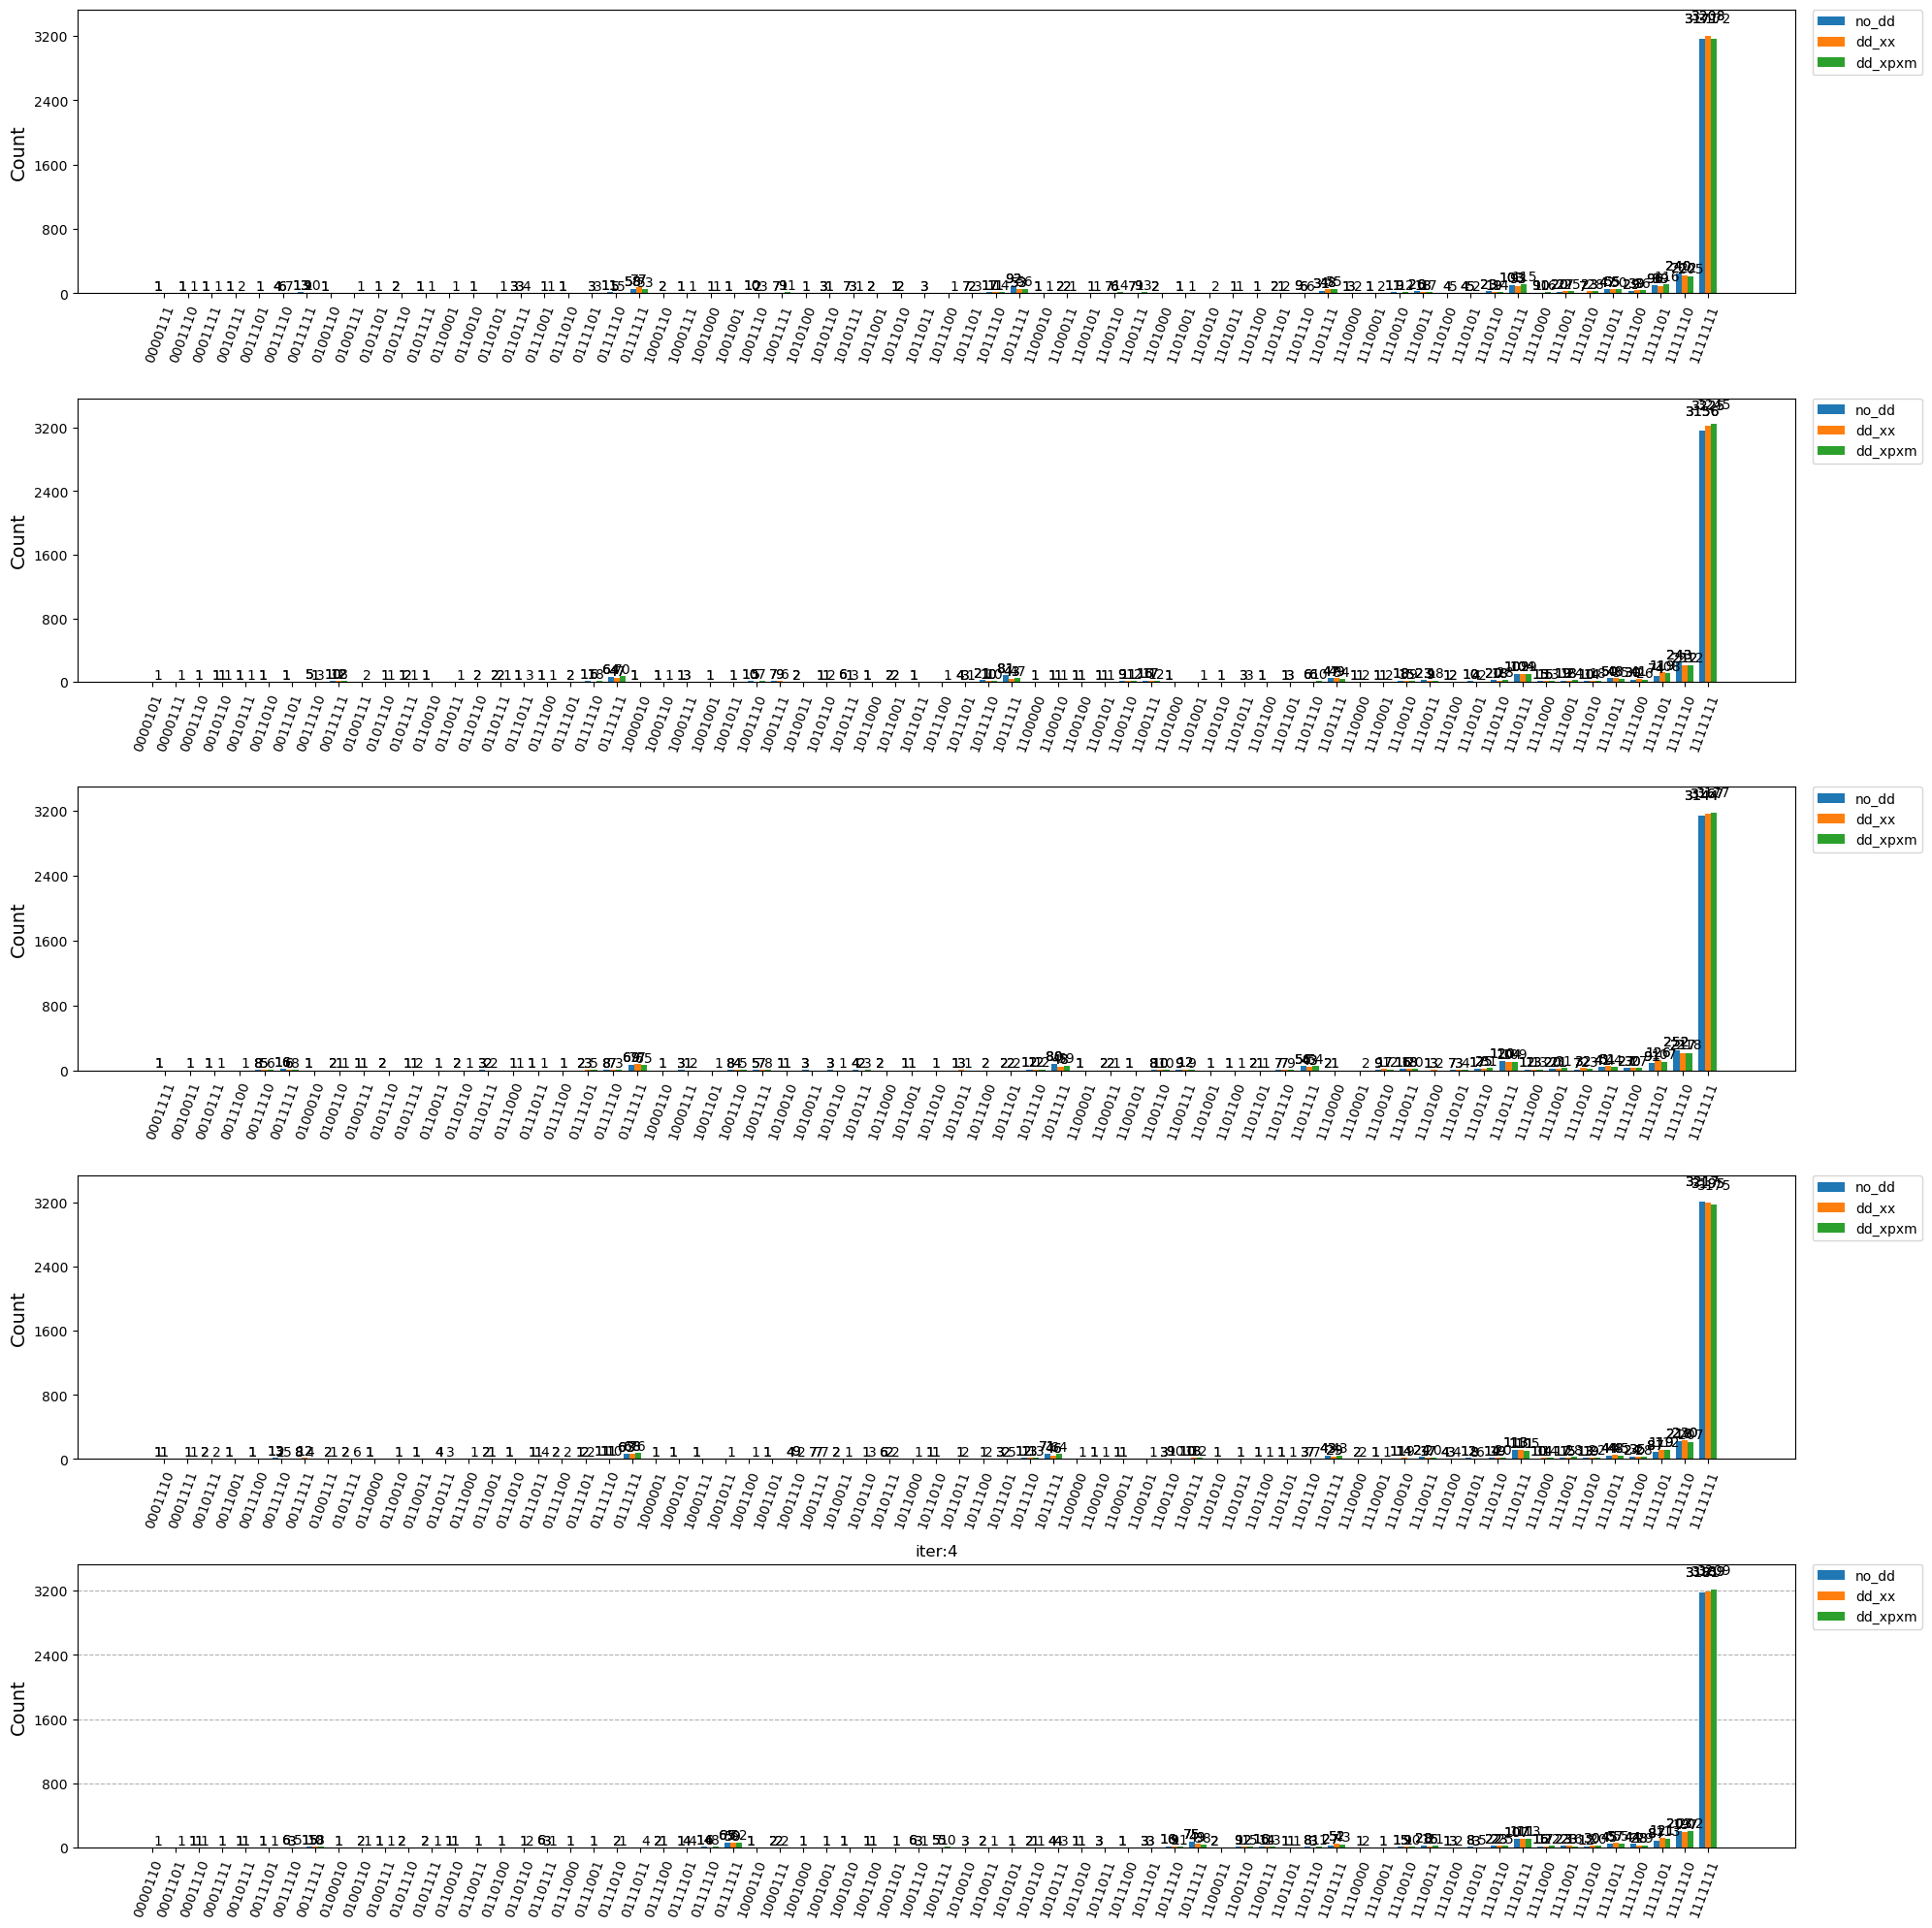

In [6]:
fig, ax = plot_all_counts(df, 7)


### Parse the results for plot

In [7]:
def view_results_and_convert_in_array(data, qubit):
    
    qubit_df = data[data["Qubit"] == qubit]

    simulated_data = []
    no_dd_data = []
    dd_xx_data = []
    dd_xpxm_data = []
    alt_no_dd_data = []
    alt_dd_xx_data = []
    alt_dd_xpxm_data = []

    for i in range(5):
        hf = qubit_df.iloc[i, 9]
        alt_hf = qubit_df.iloc[i, 10]
        print(f"For qubit: {qubit} \n Hellinger Fidelity wrt ideal (simulated, no_dd, dd):\n {hf} \n Hellinger Fidelity wrt simulated (no_dd, dd):\n {alt_hf} \n")
        
        simulated_data.append(hf[0])

        simulated_data.append(hf[0])
        no_dd_data.append(hf[1])
        dd_xx_data.append(hf[2])
        dd_xpxm_data.append(hf[3])
        alt_no_dd_data.append(alt_hf[0])
        alt_dd_xx_data.append(alt_hf[1])
        alt_dd_xpxm_data.append(alt_hf[2])    

    return [simulated_data, no_dd_data, dd_xx_data, dd_xpxm_data, alt_no_dd_data, alt_dd_xx_data, alt_dd_xpxm_data]



In [8]:
view_results_and_convert_in_array(df, 7)

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.774169921875, 0.783203125, 0.7744140625000001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.774169921875, 0.783203125, 0.7744140625000001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7705078125, 0.787353515625, 0.792236328125] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7705078125, 0.787353515625, 0.792236328125] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7675781250000001, 0.7731933593749999, 0.7756347656250001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7675781250000001, 0.7731933593749999, 0.7756347656250001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7854003906250001, 0.780029296875, 0.7751464843750001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7854003906250001, 0.780029296875, 0.7751464843750001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [

[[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 [0.774169921875,
  0.7705078125,
  0.7675781250000001,
  0.7854003906250001,
  0.776611328125],
 [0.783203125,
  0.787353515625,
  0.7731933593749999,
  0.780029296875,
  0.778564453125],
 [0.7744140625000001,
  0.792236328125,
  0.7756347656250001,
  0.7751464843750001,
  0.783447265625],
 [0.774169921875,
  0.7705078125,
  0.7675781250000001,
  0.7854003906250001,
  0.776611328125],
 [0.783203125,
  0.787353515625,
  0.7731933593749999,
  0.780029296875,
  0.778564453125],
 [0.7744140625000001,
  0.792236328125,
  0.7756347656250001,
  0.7751464843750001,
  0.783447265625]]

In [9]:

data7  = view_results_and_convert_in_array(df, 7)[1:4]
data8  = view_results_and_convert_in_array(df, 8)[1:4]
data9  = view_results_and_convert_in_array(df, 9)[1:4]
data10 = view_results_and_convert_in_array(df, 10)[1:4]


For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.774169921875, 0.783203125, 0.7744140625000001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.774169921875, 0.783203125, 0.7744140625000001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7705078125, 0.787353515625, 0.792236328125] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7705078125, 0.787353515625, 0.792236328125] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7675781250000001, 0.7731933593749999, 0.7756347656250001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7675781250000001, 0.7731933593749999, 0.7756347656250001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [1.0, 0.7854003906250001, 0.780029296875, 0.7751464843750001] 
 Hellinger Fidelity wrt simulated (no_dd, dd):
 [0.7854003906250001, 0.780029296875, 0.7751464843750001] 

For qubit: 7 
 Hellinger Fidelity wrt ideal (simulated, no_dd, dd):
 [

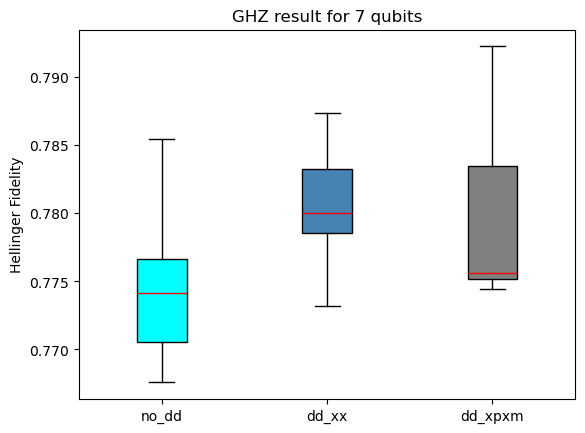

In [10]:
## For 7 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 7 qubits")

bplot = ax.boxplot(data7,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

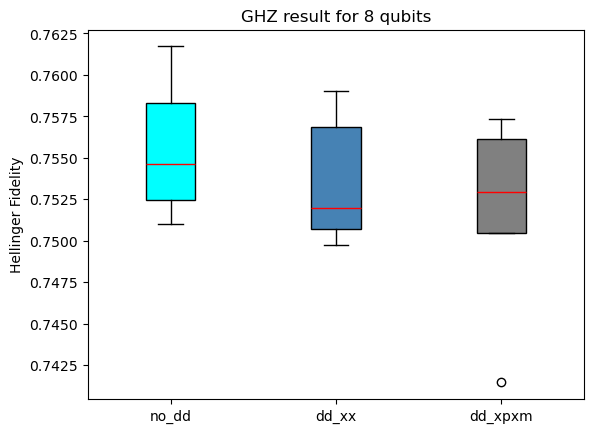

In [11]:
## For 8 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 8 qubits")

bplot = ax.boxplot(data8,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

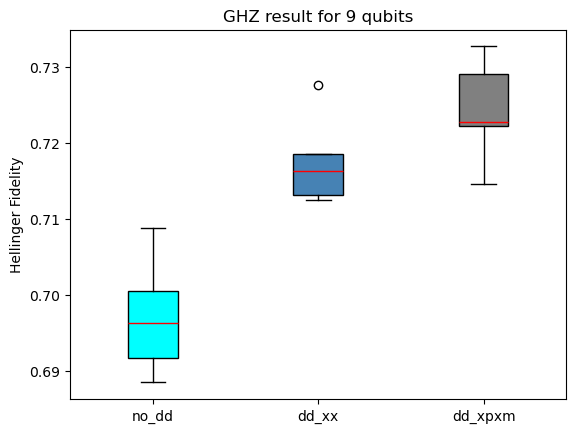

In [12]:
## For 9 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 9 qubits")

bplot = ax.boxplot(data9,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

plt.show()

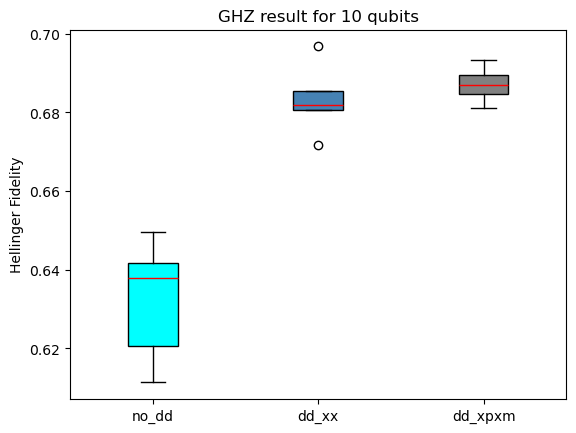

In [13]:
## For 10 Qubits

labels = ['no_dd', 'dd_xx', "dd_xpxm"]
colors = ['cyan', 'steelblue', "grey"]

fig, ax = plt.subplots()
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result for 10 qubits")

bplot = ax.boxplot(data10,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'))  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


plt.show()

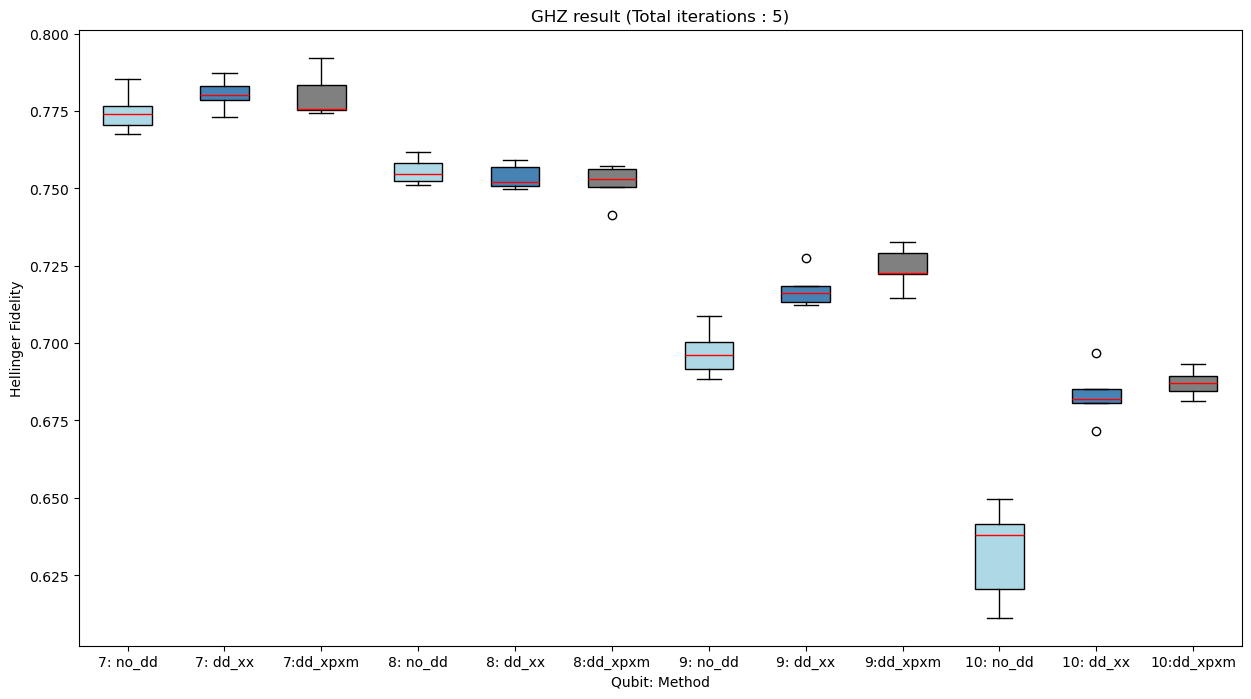

In [14]:
labels = ['7: no_dd', '7: dd_xx', '7:dd_xpxm', '8: no_dd', '8: dd_xx', '8:dd_xpxm', '9: no_dd', '9: dd_xx', '9:dd_xpxm', '10: no_dd', '10: dd_xx', '10:dd_xpxm']
colors = ['lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey', 'lightblue', 'steelblue', 'grey']

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result (Total iterations : 5)")

bplot = ax.boxplot(data7+data8+data9+data10,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   meanline=True, medianprops=dict(color='red'), manage_ticks=True)  # will be used to label x-ticks

# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

ax.set_xlabel("Qubit: Method")
plt.savefig("Fez_DD_Echo_Sampler.png")
plt.show()

NameError: name 'np' is not defined

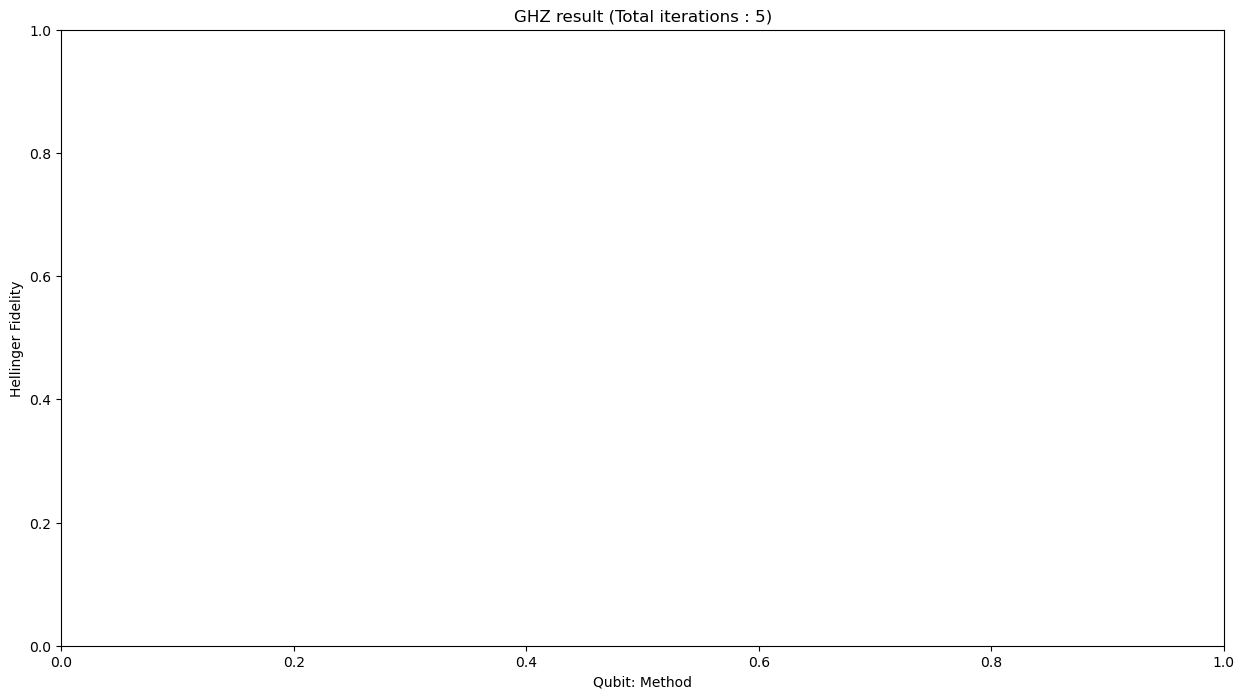

In [15]:
labels = ['7: no_dd', '7: dd_xx', '7:dd_xpxm', '8: no_dd', '8: dd_xx', '8:dd_xpxm',
          '9: no_dd', '9: dd_xx', '9:dd_xpxm', '10: no_dd', '10: dd_xx', '10:dd_xpxm']

# distinct, high-contrast colors cycling per trio
colors = ['#1f77b4', '#d62728', '#2ca02c'] * 4
datasets = data7 + data8 + data9 + data10  # list of arrays/lists

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_ylabel('Hellinger Fidelity')
ax.set_title("GHZ result (Total iterations : 5)")
ax.set_xlabel("Qubit: Method")

for i, (vals, label, color) in enumerate(zip(datasets, labels, colors), start=1):
    x = np.full(len(vals), i)
    jitter = x  # small horizontal spread
    ax.scatter(x, vals, color=color, edgecolor='k', alpha=0.8, label=label if i == 1 else None)

# vertical separators between qubit groups (every 3 categories)
for pos in [3.5, 6.5, 9.5]:
    ax.axvline(pos, color='gray', linestyle='--', linewidth=1)

ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()
